# Multiclass Classification Using Kesler's Construction

## Introduction

This notebook presents an implementation of a multiclass classifier based on Kesler's construction. The main objective is to extend a binary classification formulation to problems with more than two classes by comparing the correct class against the remaining classes.

The workflow includes loading multiple datasets, preprocessing the input variables, training the model, generating predictions, and evaluating the results using classification metrics. To analyze the behavior of the method, several datasets with different levels of complexity are used: Iris, Wine, Dry Bean, Digits, and Glass.

This project aims to demonstrate a from-scratch implementation of a multiclass classification method, highlighting both the mathematical logic of the training process and its practical application across different supervised learning scenarios.

## General objective

Implement and evaluate a multiclass classifier based on Kesler's construction, using stochastic gradient descent to adjust the model weights and analyzing its performance on different classification datasets.

## General methodology

The methodology followed in this notebook is summarized in the following stages:

1. Data loading and preparation.
2. Train-test split.
3. Standardization of numerical variables.
4. Implementation of a numerically stable sigmoid function.
5. Model training using Kesler's construction.
6. Class prediction on the test set.
7. Performance evaluation using accuracy, confusion matrices, and learning curves.

Kesler's construction transforms a multiclass problem into a class-comparison scheme, where the model learns to favor the correct class over the remaining possible classes.

## Libraries and initial configuration

This section imports the libraries required for data manipulation, numerical operations, visualization, dataset loading, preprocessing, and model evaluation.

A random seed is also set to support reproducibility in processes that depend on randomness, such as data splitting.

> **Note:** To run the Dry Bean experiment from an `.xlsx` file, the environment must support Excel file reading, for example through `openpyxl`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Note: loading .xlsx files may require installing openpyxl in the execution environment.

np.random.seed(42)

# Iris Dataset

## Dataset loading

This first experiment uses the Iris dataset, a classic multiclass classification dataset. It contains morphological measurements of flowers and three possible classes.

The purpose of this initial experiment is to validate the base implementation of the classifier on a small, balanced dataset that is widely used as a supervised learning benchmark.

In [2]:
iris = load_iris()
df = pd.DataFrame(data=iris.data)
X = df.to_numpy() # Feature matrix for the Iris dataset
df = pd.DataFrame(data=iris.target)
Y = df.to_numpy() # Class labels for the Iris dataset: 0, 1, and 2
d = X.shape[1] # Number of input features
c = np.unique(Y).size # Total number of classes in the problem

## Data splitting

In this section, the dataset is divided into training and test subsets. The stratified split preserves the class proportions in both subsets, which supports a more representative model evaluation.

In [3]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

## Feature standardization

The numerical variables are standardized so that they have a comparable scale. The scaler is fitted only on the training set and then applied to the test set.

This practice prevents information leakage from the test set into the training process.

In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Fits the scaler on the training set and transforms its variables
X_test = scaler.transform(X_test) # Transforms the test set using the statistics learned from the training set

## Implementation of the stable sigmoid function

The following implementation evaluates the sigmoid function while avoiding direct computations that may produce numerical errors. This is important because training can generate large values in the linear combinations.

In [5]:
def sigmoide(X: np.array) -> np.array:
    exp_neg_abs = np.exp(-np.abs(X))
    return np.where(
        X >= 0,
        1 / (1 + exp_neg_abs),
        exp_neg_abs / (1 + exp_neg_abs)
    )

## Mathematical Formulation of Kesler's Construction

Kesler's construction provides a way to extend a binary linear classifier to a multiclass classification problem. The main idea is to compare the score assigned to the correct class against the scores assigned to all other classes.

Assume a multiclass problem with $K$ classes and an input sample:

$$
\mathbf{x}_i \in \mathbb{R}^{d}
$$

To include the bias term, the input vector is augmented with a constant $1$:

$$
\tilde{\mathbf{x}}_i =
\begin{bmatrix}
1 \\
\mathbf{x}_i
\end{bmatrix}
$$

For each class $k$, the model learns a weight vector:

$$
\mathbf{w}_k \in \mathbb{R}^{d+1}
$$

All class weight vectors are stored in the matrix:

$$
W =
\begin{bmatrix}
\mathbf{w}_1^\top \\
\mathbf{w}_2^\top \\
\vdots \\
\mathbf{w}_K^\top
\end{bmatrix}
\in \mathbb{R}^{K \times (d+1)}
$$

The linear score assigned to class $k$ is computed as:

$$
g_k(\mathbf{x}_i) = \mathbf{w}_k^\top \tilde{\mathbf{x}}_i
$$

During prediction, the assigned class is the one with the highest discriminant score:

$$
\hat{y}_i = \arg\max_k g_k(\mathbf{x}_i)
$$

During training, if the true class of sample $i$ is $k$, Kesler's construction compares the score of the correct class $k$ against every incorrect class $j \neq k$. The margin for each comparison is defined as:

$$
\Delta_{k,j} =
(\mathbf{w}_k - \mathbf{w}_j)^\top \tilde{\mathbf{x}}_i
$$

A positive value of $\Delta_{k,j}$ means that the correct class receives a larger score than the competing class $j$. Therefore, the optimization process should increase this margin.

Using the logistic loss, the loss associated with the comparison between the correct class $k$ and an incorrect class $j$ is:

$$
L_{k,j} =
\log\left(1 + e^{-\Delta_{k,j}}\right)
$$

The total objective function is obtained by summing this loss over all samples and all incorrect classes:

$$
J(W) =
\sum_{i=1}^{n}
\sum_{j \neq y_i}
\log\left(1 + e^{-\Delta_{y_i,j}}\right)
$$

where $y_i$ is the true class of sample $i$.

The gradient update adjusts the weights so that the score of the correct class increases while the scores of the incorrect classes decrease. In general, the weight update follows the gradient descent rule:

$$
W^{(t+1)} =
W^{(t)}
-
\eta
\frac{\partial J(W)}{\partial W}
$$

where $\eta$ is the learning rate.

In the implementation, the gradient is accumulated for each sample by comparing the true class against every other class. For each comparison, the update increases the weight vector of the correct class and decreases the weight vector of the competing incorrect class. This directly follows the principle of Kesler's construction: the classifier learns to separate each class by enforcing pairwise inequalities between class scores.

This formulation is important because it connects the mathematical objective with the training function implemented below. The model does not rely on a built-in multiclass classifier; instead, it explicitly learns a set of linear discriminant functions using the pairwise comparison structure defined by Kesler's construction.

## Training with Kesler's construction

This section implements the training process for the multiclass classifier. For each sample, the model compares the correct class against the remaining classes and accumulates the loss associated with those comparisons.

The procedure updates the weight matrix using a gradient-based rule. The total loss per epoch is stored so that the learning curve can be visualized later.

This is the central stage of the project, since it contains the main logic of the classifier implemented from scratch.

In [ ]:
def kesler_MClass(X:np.array, Y:np.array, epocas:int, eta:float):

    k_num = len(np.unique(Y))
    n, d = X.shape
    d1 = d + 1
    W = np.zeros((k_num, d1))
    L = []

    for epoca in range(epocas):
        perdida_total = 0.0

        for i in range(n):    
            x = X[i]
            k = int(np.ravel(Y)[i]) + 1
            x_ext = np.concatenate(([1.0], x)) # Adds the bias term to the feature vector

            G = np.zeros((k_num, d1))
            loss_muestra = 0

            for j in range(1, k_num + 1):

                if j == k:
                    continue

                delta = (W[k - 1] - W[j - 1]) @ x_ext
                p = sigmoide(delta)
                # Direct form of the logistic loss; replaced by a more stable version
                L_kj = np.logaddexp(0, -delta)   # Numerically stable calculation of the logistic loss
                loss_muestra += L_kj

                # Equivalent form of the gradient expressed with the sigmoid function
                g = (p - 1) * x_ext   # Gradient associated with the comparison between the correct class and an alternative class
                G[k - 1] += g
                G[j - 1] -= g
              
            perdida_total += loss_muestra
            W += -eta * G

        L.append(perdida_total)

    return W, L

## Initial prediction and evaluation

After training, the learned weight matrix is used to compute a linear score for each class. The predicted class corresponds to the index with the highest score.

The model is initially evaluated using accuracy on the test set. This metric represents the proportion of correctly classified samples.

In [7]:
def predict_perceptron(X, W):
    n = X.shape[0]
    X_aug = np.column_stack((np.ones(n), X))  # Adds the bias term to all samples
    Prb = X_aug @ W.T # Computes the linear discriminant function for each class
    Ypp = np.argmax(Prb, axis=1)  # Assigns the class with the highest linear score
    Ypp = Ypp.reshape(-1, 1) # Converts predictions to column-vector format
    return Ypp

# Defines the training hyperparameters
epocas = 100
eta = 0.1

# Trains the multiclass classifier
W, L = kesler_MClass(X_train, Y_train, epocas, eta)

# Generates predictions on the test set
Y_pred = predict_perceptron(X_test, W)

# Computes accuracy on the test set
accuracy = np.mean(Y_pred == Y_test)
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 1.0000


## Confusion matrix for the Iris dataset

The confusion matrix makes it possible to observe the model behavior by class. Each row represents the true class, and each column represents the predicted class.

A high concentration of values on the main diagonal indicates that the model correctly classifies most observations. Values outside the diagonal correspond to classification errors.

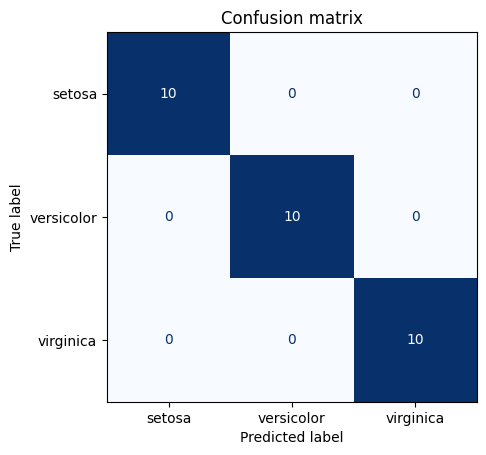

Accuracy: 1.000


In [8]:
cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(colorbar=False, cmap='Blues')
plt.title('Confusion matrix')
plt.show()
ACC = np.mean(Y_pred == Y_test)
print(f"Accuracy: {ACC:.3f}")

## Learning curve for the Iris dataset

The learning curve shows the evolution of the loss function `J(w)` across the training epochs.

A decreasing trend indicates that the model is progressively reducing the error during training. This plot helps analyze whether the training process converges, whether the loss stabilizes, or whether possible numerical issues appear during optimization.

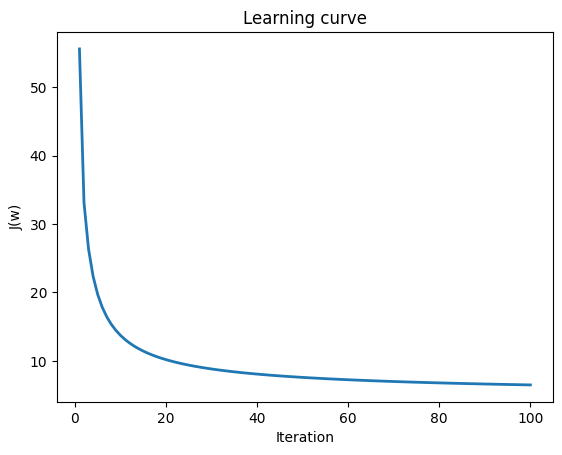

In [9]:
plt.figure(facecolor='w')
plt.plot(range(1, epocas + 1), L, linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('J(w)')
plt.title('Learning curve')
plt.show()

# Wine Dataset

## Dataset description and loading

This section evaluates the classifier using the Wine dataset, a multiclass classification dataset related to chemical properties of different types of wine.

The column names are defined and the `wine.data` file is loaded. The first column corresponds to the class, while the remaining columns contain the chemical features used as input variables.

This dataset makes it possible to evaluate the method on a problem with numerical variables on different scales and with a structure different from Iris. This helps verify whether the classifier maintains good performance in another data domain.

In [10]:
from sklearn.datasets import load_wine

wine = load_wine()

X = wine.data
y = wine.target

df = pd.DataFrame(X, columns=wine.feature_names)
df["Class"] = y

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Preprocessing, training, and evaluation on Wine

In this section, features and labels are separated, the class labels are adjusted to start from zero, the dataset is divided into training and test subsets, and the numerical variables are standardized.

Then, the same Kesler-based classifier is trained and its accuracy is computed on the test set.

In [11]:
X_1 = df.drop(columns="Class").to_numpy()
Y_1 = df["Class"].to_numpy()

X_train_1, X_test_1, Y_train_1, Y_test_1 = train_test_split(
    X_1,
    Y_1,
    test_size=0.2,
    random_state=42,
    stratify=Y_1
)

scaler = StandardScaler()

X_train_1 = scaler.fit_transform(X_train_1)  # Fits the scaler only on the training set
X_test_1 = scaler.transform(X_test_1)        # Transforms the test set using the statistics learned from the training set

# Defines the training hyperparameters
epocas = 100
eta = 0.1

# Trains the multiclass classifier
W1, L1 = kesler_MClass(X_train_1, Y_train_1, epocas, eta)

# Generates predictions on the test set
Y_pred_1 = predict_perceptron(X_test_1, W1)

# Computes accuracy on the test set
accuracy = np.mean(Y_pred_1.flatten() == Y_test_1.flatten())
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.9722


## Confusion matrix for the Wine dataset

The confusion matrix complements the global accuracy score because it shows how correct and incorrect predictions are distributed across the wine classes.

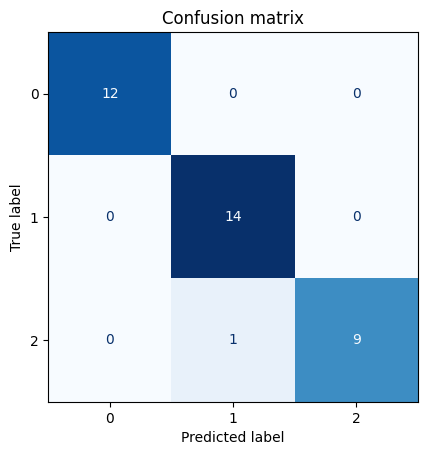

Accuracy: 0.972


In [12]:
cm = confusion_matrix(Y_test_1, Y_pred_1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(Y_1))
disp.plot(colorbar=False, cmap='Blues')
plt.title('Confusion matrix')
plt.show()
ACC = np.mean(Y_pred_1.flatten() == Y_test_1.flatten())
print(f"Accuracy: {ACC:.3f}")

## Learning curve for the Wine dataset

This plot makes it possible to verify whether the loss decreases during training, which helps interpret the behavior of the optimization process for this dataset.

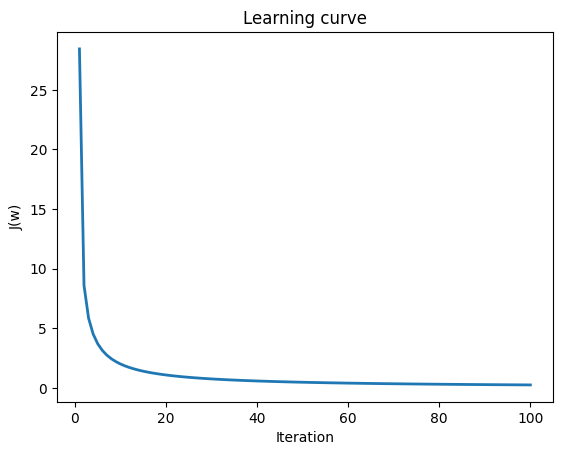

In [13]:
plt.figure(facecolor='w')
plt.plot(range(1, epocas + 1), L1, linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('J(w)')
plt.title('Learning curve')
plt.show()

# Dry Bean Dataset

## Dataset description and loading

This section uses the Dry Bean dataset, which contains morphological characteristics of bean grains and multiple possible classes.

The dataset is loaded from an Excel file. The initial visualization with `head()` helps verify the column structure and confirm that the data was read correctly.

This dataset represents a larger and more complex case compared with Iris and Wine. Therefore, it makes it possible to observe the behavior of the method on a more demanding multiclass problem.

In [14]:
# Load dataset 

df = pd.read_excel("../data/Dry_Bean_Dataset.xlsx")
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


## Class encoding

The original labels in the dataset are categorical. To train the classifier, each class is transformed into an integer numerical value.

In [15]:
# Encodes categorical classes as numerical values.

clases = {'SEKER': 0, 'BARBUNYA': 1, 'BOMBAY': 2, 'CALI': 3, 'HOROZ': 4, 'SIRA': 5, 'DERMASON': 6}
df['Class'] = df['Class'].map(clases).values

## Preprocessing, training, and evaluation on Dry Bean

In this section, the features and target label are separated, the dataset is divided into training and test subsets, the variables are standardized, and the classifier is trained.

The final accuracy summarizes the global performance of the model on the test set.

In [16]:
X_2 = df.iloc[:, :16].to_numpy()
Y_2 = df.iloc[:, 16].to_numpy()

X_train_2, X_test_2, Y_train_2, Y_test_2 = train_test_split(X_2, Y_2, test_size=0.2, random_state=42, stratify=Y_2)

X_train_2 = scaler.fit_transform(X_train_2)   # Fits the scaler only on the training set
X_test_2 = scaler.transform(X_test_2)  # Transforms the test set using the statistics learned from the training set

# Defines the training hyperparameters
epocas = 100
eta = 0.005

# Trains the multiclass classifier
W2, L2 = kesler_MClass(X_train_2, Y_train_2, epocas, eta)

# Generates predictions on the test set
Y_pred_2 = predict_perceptron(X_test_2, W2)

# Computes accuracy on the test set
accuracy = np.mean(Y_pred_2.flatten() == Y_test_2.flatten())
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.9203


/var/folders/kw/92dmrbxd2gn0ywkrh3hf7qs40000gn/T/ipykernel_62461/1863616215.py:4: RuntimeWarning: divide by zero encountered in matmul
  Prb = X_aug @ W.T # Computes the linear discriminant function for each class
/var/folders/kw/92dmrbxd2gn0ywkrh3hf7qs40000gn/T/ipykernel_62461/1863616215.py:4: RuntimeWarning: overflow encountered in matmul
  Prb = X_aug @ W.T # Computes the linear discriminant function for each class
/var/folders/kw/92dmrbxd2gn0ywkrh3hf7qs40000gn/T/ipykernel_62461/1863616215.py:4: RuntimeWarning: invalid value encountered in matmul
  Prb = X_aug @ W.T # Computes the linear discriminant function for each class


## Confusion matrix for the Dry Bean dataset

The confusion matrix helps identify which classes are classified correctly and which classes present greater confusion.

For datasets with several classes, this visualization is especially useful because the global accuracy score does not always show where the errors are concentrated.

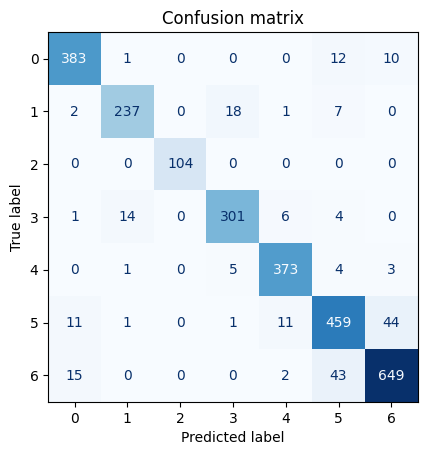

Accuracy: 0.920


In [17]:
cm = confusion_matrix(Y_test_2, Y_pred_2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(Y_2))
disp.plot(colorbar=False, cmap='Blues')
plt.title('Confusion matrix')
plt.show()
ACC = np.mean(Y_pred_2.flatten() == Y_test_2.flatten())
print(f"Accuracy: {ACC:.3f}")

## Learning curve for the Dry Bean dataset

The learning curve makes it possible to observe the evolution of the loss during training.

If numerical warnings appear during execution, they should be interpreted as a sign that the training stability or hyperparameters may need to be reviewed in future work.

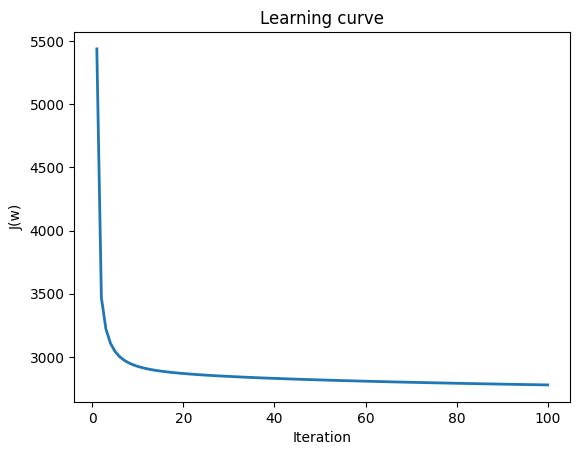

In [18]:
plt.figure(facecolor='w')
plt.plot(range(1, epocas + 1), L2, linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('J(w)')
plt.title('Learning curve')
plt.show()

# Digits Dataset

## Dataset description and loading

This section evaluates the classifier with the Digits dataset, which contains small images of handwritten digits represented as numerical vectors.

The images and their labels are loaded from `sklearn.datasets`. The images are represented as numerical vectors, allowing the implemented classifier to be applied directly.

This dataset tests the classifier on a problem with a larger number of classes and image-derived features, expanding the analysis beyond traditional tabular datasets.

In [19]:
digits = load_digits()
df = pd.DataFrame(data=digits.data)
X3 = df.to_numpy()
df = pd.DataFrame(data=digits.target)
Y3 = df.to_numpy()

## Splitting and standardizing the Digits dataset

The dataset is divided into training and test subsets using stratification to preserve the class proportions. Then, the numerical variables are standardized to support the training process.

In [20]:
X_train_3, X_test_3, Y_train_3, Y_test_3 = train_test_split(X3, Y3, test_size=0.2, random_state=42, stratify=Y3)

X_train_3 = scaler.fit_transform(X_train_3) # Fits the scaler on the training set and transforms its variables
X_test_3 = scaler.transform(X_test_3) # Transforms the test set using the statistics learned from the training set

## Training and evaluation on Digits

In this section, the multiclass classifier is trained on the Digits dataset and the accuracy is computed on the test set.

In [21]:
# Defines the training hyperparameters
epocas = 100
eta = 0.005

# Trains the multiclass classifier
W3, L3 = kesler_MClass(X_train_3, Y_train_3, epocas, eta)

# Generates predictions on the test set
Y_pred_3 = predict_perceptron(X_test_3, W3)

# Computes accuracy on the test set
accuracy = np.mean(Y_pred_3.flatten() == Y_test_3.flatten())
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.9583


/var/folders/kw/92dmrbxd2gn0ywkrh3hf7qs40000gn/T/ipykernel_62461/1863616215.py:4: RuntimeWarning: divide by zero encountered in matmul
  Prb = X_aug @ W.T # Computes the linear discriminant function for each class
/var/folders/kw/92dmrbxd2gn0ywkrh3hf7qs40000gn/T/ipykernel_62461/1863616215.py:4: RuntimeWarning: overflow encountered in matmul
  Prb = X_aug @ W.T # Computes the linear discriminant function for each class
/var/folders/kw/92dmrbxd2gn0ywkrh3hf7qs40000gn/T/ipykernel_62461/1863616215.py:4: RuntimeWarning: invalid value encountered in matmul
  Prb = X_aug @ W.T # Computes the linear discriminant function for each class


## Confusion matrix for the Digits dataset

The confusion matrix makes it possible to observe which digits concentrate the largest number of errors. This helps interpret performance beyond the global accuracy score.

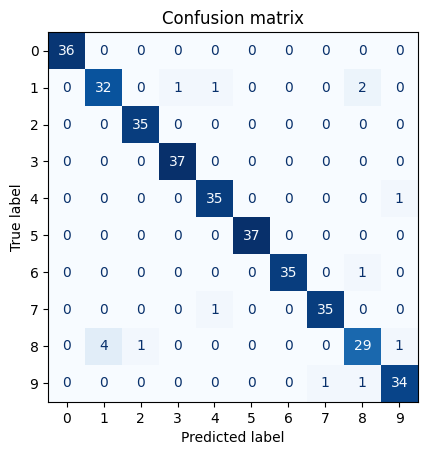

Accuracy: 0.958


In [22]:
cm = confusion_matrix(Y_test_3, Y_pred_3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits.target_names)
disp.plot(colorbar=False, cmap='Blues')
plt.title('Confusion matrix')
plt.show()
accuracy = np.mean(Y_pred_3.flatten() == Y_test_3.flatten())
print(f"Accuracy: {accuracy:.3f}")

## Learning curve for the Digits dataset

The learning curve shows the evolution of the loss during training. This plot makes it possible to visually evaluate whether the optimization process progressively reduces the error.

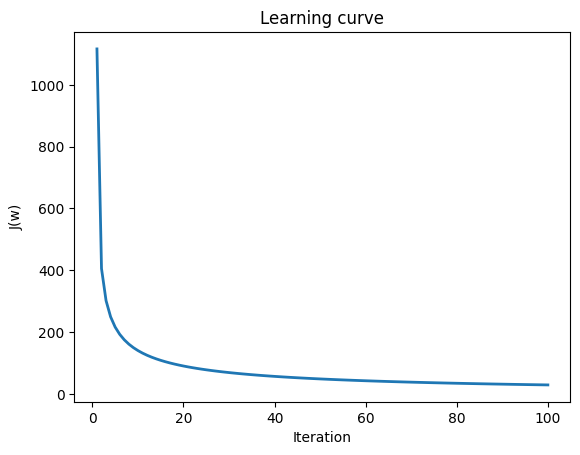

In [23]:
plt.figure(facecolor='w')
plt.plot(range(1, epocas + 1), L3, linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('J(w)')
plt.title('Learning curve')
plt.show()

# Glass Dataset

## Dataset description and loading

This section uses the Glass dataset, a multiclass classification dataset associated with chemical properties of different types of glass.

The dataset is loaded from a CSV file. The target variable corresponds to the glass type, and the remaining columns contain the features used for classification.

This dataset makes it possible to evaluate the classifier on a smaller dataset with potential class imbalance. This can affect model performance and helps analyze the method's limitations in scenarios where some classes have few available observations.

In [31]:
df = pd.read_csv("../data/glass.csv")
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## Preprocessing, training, and evaluation on Glass

In this section, the features and target variable are separated, and the labels are adjusted to work with consecutive indices.

Then, the train-test split, standardization, model training, and accuracy-based evaluation are performed.

In [33]:
X_4 = df.iloc[:, :9].to_numpy()
Y_4 = df.Type.to_numpy()
Y_4 = np.where(Y_4 >= 5, Y_4 - 1, Y_4)
Y_4 = Y_4 - 1

X_train_4, X_test_4, Y_train_4, Y_test_4 = train_test_split(X_4, Y_4, test_size=0.2, random_state=42, stratify=Y_4)

X_train_4 = scaler.fit_transform(X_train_4)   # Fits the scaler only on the training set
X_test_4 = scaler.transform(X_test_4)  # Transforms the test set using the statistics learned from the training set

# Defines the training hyperparameters
epocas = 100
eta = 0.1

# Trains the multiclass classifier
W4, L4 = kesler_MClass(X_train_4, Y_train_4, epocas, eta)

# Generates predictions on the test set
Y_pred_4 = predict_perceptron(X_test_4, W4)

# Computes accuracy on the test set
accuracy = np.mean(Y_pred_4.flatten() == Y_test_4.flatten())
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.6977


## Confusion matrix for the Glass dataset

Because the Glass dataset may present important differences in the number of observations per class, the confusion matrix is especially useful for interpreting the model's errors.

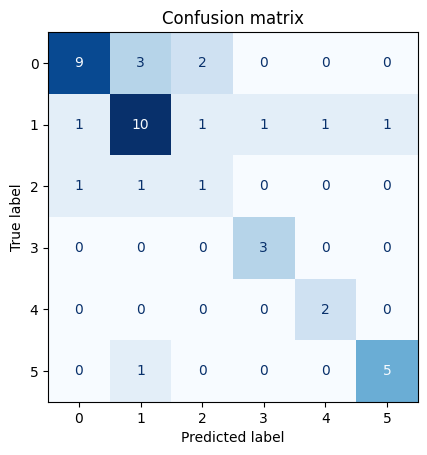

Accuracy: 0.698


In [34]:
cm = confusion_matrix(Y_test_4, Y_pred_4)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(Y_4))
disp.plot(colorbar=False, cmap='Blues')
plt.title('Confusion matrix')
plt.show()
accuracy = np.mean(Y_pred_4.flatten() == Y_test_4.flatten())
print(f"Accuracy: {accuracy:.3f}")

## Learning curve for the Glass dataset

The learning curve makes it possible to observe whether the loss function decreases during training and whether the optimization process behaves in a stable manner.

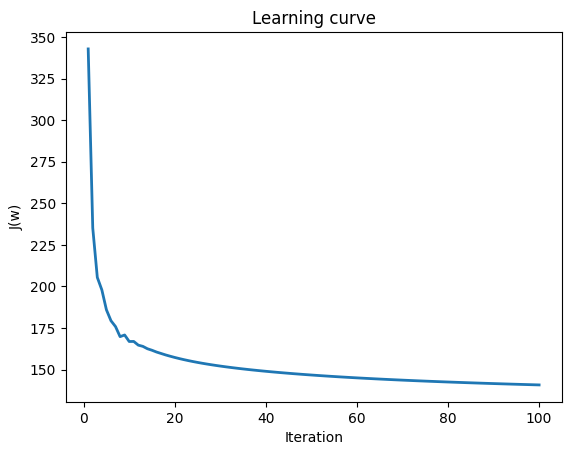

In [35]:
plt.figure(facecolor='w')
plt.plot(range(1, epocas + 1), L4, linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('J(w)')
plt.title('Learning curve')
plt.show()

## Class distribution in the Glass dataset

The class distribution shows how many observations are available for each glass type. This information helps contextualize model performance, especially when some classes have fewer examples.

In [36]:
df['Type'].value_counts().sort_index()

Type
1    70
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64

## Experimental Results

This section summarizes the performance obtained by the Kesler-based multiclass classifier across the evaluated datasets. Each experiment followed the same general workflow: dataset loading, train-test split, feature standardization, model training, prediction, and evaluation on the test set.

The main evaluation metric used in this notebook is **test accuracy**, which measures the proportion of correctly classified samples in the test set. In addition, confusion matrices and learning curves are included for each dataset to provide a more detailed interpretation of the model behavior.

---

## Results Summary

| Dataset  | Number of Classes | Test Accuracy |
| -------- | ----------------: | ------------: |
| Iris     |                 3 |        1.0000 |
| Wine     |                 3 |        0.9722 |
| Dry Bean |                 7 |        0.9203 |
| Digits   |                10 |        0.9583 |
| Glass    |                 6 |        0.6977 |

The results show that the Kesler-based classifier achieved strong performance on most of the evaluated datasets. The highest accuracy was obtained on the Iris dataset, where the model correctly classified all test samples. High accuracy was also observed on the Wine, Dry Bean, and Digits datasets, suggesting that the implemented method is able to handle multiclass classification problems with different numbers of features and classes.

The Glass dataset obtained the lowest accuracy among the evaluated datasets. This result is expected to some extent, since Glass is a smaller and more challenging dataset, with fewer observations and a more imbalanced class distribution. In this case, accuracy alone should be interpreted carefully, and the confusion matrix provides additional insight into which classes are harder to separate.

---

## Interpretation of Confusion Matrices

The confusion matrices provide a class-level view of the model predictions. Values on the main diagonal represent correctly classified samples, while values outside the diagonal correspond to misclassifications.

For datasets such as Iris, Wine, Dry Bean, and Digits, the confusion matrices show a strong concentration of values along the diagonal, which indicates that the classifier learned effective decision boundaries for most classes.

For the Glass dataset, the confusion matrix shows a higher number of off-diagonal values. This suggests that some glass types are more difficult to distinguish based on the available features. This behavior may be related to class imbalance, small sample size, or overlapping feature distributions between certain classes.

---

## Interpretation of Learning Curves

The learning curves show the evolution of the objective function (J(W)) across training epochs. These curves are useful for analyzing whether the optimization process is reducing the loss over time.

A decreasing learning curve indicates that the model is progressively improving its classification objective during training. In the experiments, the loss generally decreases as the number of epochs increases, which suggests that the gradient-based update rule is able to optimize the Kesler-based objective function.

However, the scale and smoothness of the learning curves may vary across datasets. Larger or more complex datasets may require different learning rates, more epochs, or additional numerical stabilization strategies to improve convergence behavior.

---

## General Discussion

Overall, the experimental results indicate that Kesler's construction can be used as an effective strategy for multiclass classification when combined with a logistic loss and gradient-based optimization.

The main strength of this implementation is that the multiclass classifier is built from first principles. Instead of relying on a built-in machine learning model, the notebook explicitly defines the loss function, the gradient-based weight update, and the prediction rule.

The results also show that the model performs better on datasets with clearer class separation, such as Iris and Wine. On more complex or imbalanced datasets, such as Glass, the performance decreases, highlighting the importance of evaluating multiclass classifiers not only with accuracy but also with class-level diagnostic tools such as confusion matrices.

These findings suggest that the implemented method is a valid educational and experimental approach for understanding multiclass classification, linear discriminant functions, and optimization-based model training.


# Conclusions

This notebook implemented a multiclass classifier based on Kesler's construction and evaluated its performance on different supervised classification datasets.

The results show that the implementation can reach different performance levels depending on the characteristics of each dataset. On classic and relatively structured datasets, such as Iris and Wine, the method provides a clear way to analyze the behavior of both training and classification. On more complex datasets, with higher dimensionality, more classes, or potential class imbalance, performance may vary, which makes it possible to study the strengths and limitations of the method in a more realistic way.

The project also highlights the importance of preprocessing, especially feature standardization, as well as visual evaluation tools such as confusion matrices and learning curves for interpreting model behavior.